In [1]:
import modules.utils as u
u.Devices()._cuda_list_gpus()

[('cuda:1', 'NVIDIA A100-SXM4-80GB', 81043),
 ('cuda:4', 'NVIDIA A100-SXM4-80GB', 81043),
 ('cuda:6', 'NVIDIA A100-SXM4-80GB', 81043),
 ('cuda:2', 'NVIDIA A100-SXM4-80GB', 81041),
 ('cuda:3', 'NVIDIA A100-SXM4-80GB', 81041),
 ('cuda:7', 'NVIDIA A100-SXM4-80GB', 81041),
 ('cuda:0', 'NVIDIA A100-SXM4-80GB', 79361),
 ('cuda:5', 'NVIDIA A100-SXM4-80GB', 74623)]

In [2]:
#### mv packages ####
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device, generator = u.Devices().auto_set_device(drop=['cuda:1','cuda:6'])

#### data ####
brca = d.TCGA(
    tcga_project = 'BRCA',
    tcga_dir = dataset_dir/'tcga',
    # type_col = 'sample_type',
    subtype_col = 'paper_BRCA_Subtype_PAM50',
    drop = ['Normal', 'Primary Tumor', 'Metastatic'],
    gene_name_path = dataset_dir/'other'/'name2ensg.csv',
    keep_noname = False,
)

kegg = d.KEGG(
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv', 
    counts_data=brca,
)

data = d.Preprocessor(brca, kegg, kegg, class_wt_method='inverse')
_dataset = d.GraphDataset(data)
_batch = d.get_toy_databatch(_dataset, generator)

# #### Device() ####
# device = cuda:4

# #### KEGG() ####
# relation                 (75939, 19)              DataFrame
# ensg                     4373                     list
# pathway_labels           305                      list
# edge_index               (2, 32464)               Tensor (cuda:4)
# edge_attr                (32464, 16)              Tensor (cuda:4)
# edge_labels              16                       list
# pathway_index            (4373, 305)              Tensor (cuda:4)

# #### TCGA() ####
# counts_path              PosixPath
# metadata_path            PosixPath
# gene_name_path           PosixPath
# metadata_complete        (1231, 93)               DataFrame
# metadata                 (1172, 2)                DataFrame
# y                        (1172,)                  Tensor (cuda:4)
# y_labels                 5                        list
# ensgv                    (60660, 3)               DataFrame
# ensg_complete            19213                    list
# cou

---

In [3]:
import modules.model as m
import modules.layers as l
import modules.train as t

import torch.nn as nn

In [4]:
# mlp = m.Autoencoder(
#     # dims
#     data=data,
#     head_dim=8,
#     num_heads=16,
    
#     # layers
#     nb=False,
#     encoder_class=nn.Linear,
#     pooling_class=l.SetPooling,
#     mlp=False,
#     method='node',

#     # layer params
#     hidden_dims=[64,64], 
#     act_fn=nn.ReLU, 
#     norm_fn='layer', 
#     end_fn=False,
# )

In [5]:
# loader = t.Loader(
#     dataset = _dataset,
#     generator = generator,
#     batch_size = 128
# )

# trainer = t.ReconTrainer(
#     loss_fn=nn.MSELoss(),
#     optimizer_kwargs={'lr':5e-4},
#     verbose=True,
#     report_metrics=['loss','mae','r2']
# )

# # trainer.run(
# #     model = mlp,
# #     loader = loader,
# #     num_epochs = 100
# # )

---

In [6]:
from modules.layers import Sequential, SetPooling
from modules.model import Dims
from modules.utils import input_to_dict, reshape, cloneable

import copy
import torch
import torch.nn as nn

# typing
from modules.data import Preprocessor
from torch import Tensor
from torch_geometric.data import Data
from typing import Callable, Literal, Type, Union

In [7]:
from modules.layers import AttentionSetPooling
from modules.train import Loader
from modules.utils import dict_summary
from torch_geometric.nn import GCNConv, GATConv

In [8]:
dims = Dims(
    data=data,
    head_dim=8,
    num_heads=2
)

---

In [9]:
@cloneable
class Normalizer(nn.Module): 
    # parent class template, change in child
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def init_with_loader(self, loader:Loader):
        pass

    def transform(self, x):
        return x
    
    def revert(self, x):
        return x

In [10]:
@cloneable
class logNorm(Normalizer):
    def transform(self, x):
        return torch.log1p(x)

    def revert(self, x):
        return torch.expm1(x)

In [11]:
@cloneable
class ZlogNorm(Normalizer):
    def init_with_loader(self, loader:Loader):
        self.num_nodes = loader.dataset[0].num_nodes
        self.num_features = loader.dataset[0].num_features
        self.log_mean = loader.stats['log_mean']
        self.log_std = loader.stats['log_std']

    def transform(self, x):
        x = reshape(x, 'b,n,f', num_nodes=self.num_nodes, num_features=self.num_features)
        log_x = torch.log1p(x)
        z = (log_x - self.log_mean)/self.log_std
        z = reshape(z, 'b*n,f', num_nodes=self.num_nodes, num_features=self.num_features)
        return z
    
    def revert(self, z):
        z = reshape(z, 'b,n,f', num_nodes=self.num_nodes, num_features=self.num_features)
        log_x = (z * self.log_std) + self.log_mean
        return torch.expm1(log_x)

---

In [12]:
def clone_or_init(
   name:str,
   obj:Union[nn.Module, Type[nn.Module]],
   base_class:Type[nn.Module],
   builder: Callable[[Type[nn.Module]], nn.Module]
) -> nn.Module:
   # if (predefined) instance
   if isinstance(obj, base_class):
      if callable(getattr(obj, "clone", None)): 
         return obj.clone() # clone if applicable
      return copy.deepcopy(obj) # else deepcopy

   # elif (not defined) class
   elif isinstance(obj, type) and issubclass(obj, base_class):
      return builder(obj)

   # else error case
   raise TypeError(
      f"{name} must be a {base_class.__name__} instance or subclass, got {type(obj)}"
   )   

In [13]:
@cloneable
class Encoder(nn.Module):
    def __init__(
        self,
        dims:Dims,
        method:Literal['node','set']='node', # twin removed for now

        # layers
        norm_class:Normalizer=None,
        encoder_class:nn.Module=None,
        pooling_class:SetPooling=None,

        # new layer params
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        # kwargs
        norm_kwargs:dict={},
        encoder_kwargs:dict={},
        pooling_kwargs:dict={},

        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)
        self.method=method

        # dims
        self.mask = dims.mask
        self.embed_dim = dims.embed_dim
        self.num_nodes = dims.num_nodes
        self.num_node_features = dims.num_node_features

        # init norm
        if norm_class is None:
            self.norm = Normalizer()
        else:
            self.norm = clone_or_init(
                name='norm_class',
                obj=norm_class,
                base_class=nn.Module,
                builder=lambda cls: cls(**norm_kwargs)
            )

        # init layers
        self.node_encoder = clone_or_init(
            name='encoder_class',
            obj=encoder_class,
            base_class=nn.Module,
            builder=lambda cls: Sequential(
                in_channels=self.num_node_features,
                out_channels=self.embed_dim,
                layer_class=cls,
                hidden_dims=hidden_dims,
                act_fn=act_fn,
                norm_fn=norm_fn,
                end_fn=end_fn,
                layer_kwargs=encoder_kwargs,
            )
        )

        # init pooling if method != 'node'
        if method == 'node':
            self.node_pooling = None
        else:
            self.node_pooling = clone_or_init(
                name='pooling_class',
                obj=pooling_class,
                base_class=SetPooling,
                builder = lambda cls: cls(
                    mask=self.mask,
                    num_features=self.embed_dim,
                    hidden_dims=hidden_dims,
                    act_fn=act_fn,
                    norm_fn=norm_fn,
                    end_fn=end_fn,
                    **pooling_kwargs
                )
            )

    def init_with_loader(self, loader): # pass loader to Encoder -> Norm
        if callable(getattr(self.norm, 'init_with_loader', None)):
            self.norm.init_with_loader(loader)

    def _normalize(self, data:dict):
        # ensure x is float
        data['x'] = data['x'].float() 

        # transform x to norm
        data['x'] = self.norm.transform(data['x'])

        return data

    def _encode(self, data:dict, need_weights:bool, **kwargs):
        # get node embedding
        ne_out = self.node_encoder(data, return_dict=need_weights, return_attention_weights=need_weights, **kwargs)

        # extract node embedding from output
        if isinstance(ne_out, Tensor):
            h_node = ne_out
        else:
            ne_out = input_to_dict(ne_out) # extract as dict
            h_node = ne_out.pop('x')

        # reshape to b,n,f (for pooling)
        h_node = reshape(h_node, 'b,n,f', num_nodes=self.num_nodes, num_features=self.embed_dim)

        return h_node, ne_out

    def _pool(self, h_node:Tensor, need_weights:bool):
        # no pooling
        if self.node_pooling is None:
            return h_node, {}
        
        # pooling
        else:
            # concat if method 'twin'
            concat = True if self.method == 'twin' else False

            # get pooled embedding
            np_out = self.node_pooling(h_node, concat=concat, return_dict=need_weights)

            # extract output
            if isinstance(np_out, Tensor):
                h_pool = np_out
            else:
                np_out = input_to_dict(np_out) # extract as dict
                h_pool = np_out.pop('x')

            return h_pool, np_out

    def forward(self, input:Union[Data, Tensor, dict], need_weights:bool=False, **kwargs):
        # extract x
        data = input_to_dict(input)

        # normalize
        data = self._normalize(data)

        # node embedding
        x, ne_out = self._encode(data, need_weights, **kwargs)
        h_node = x
        
        # node pooling
        x, np_out = self._pool(x, need_weights)
        h_pool = x if self.node_pooling is not None else None

        # format output
        out = {}
        out['x'] = x
        # out['mu'] = data.get('mu') # nbloss
        # out['theta'] = data.get('theta') # nbloss

        if need_weights:
            out['layer_outs'] = {}
            out['layer_outs']['ne'] = ne_out
            out['layer_outs']['np'] = np_out
            out['h_node'] = h_node
            out['h_pool'] = h_pool
        
        return out


---

In [14]:
@cloneable
class Latent(nn.Module):
    def __init__(
        self,
        dims:Dims,

        # layers
        mlp:Union[bool,nn.Module]=False,
        pooling_class:SetPooling=SetPooling,

        # new layer params
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,   

        # kwargs
        mlp_kwargs:dict={},
        pooling_kwargs:dict={},
        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)
        
        # dims
        self.embed_dim = dims.embed_dim
        self.n_dim = dims.n_dim

        # init mlp
        if mlp is False:
            self.mlp = None
        else:
            if mlp is True: # use default (nn.Linear)
                mlp = nn.Linear 
            self.mlp = clone_or_init(
                name='mlp',
                obj=mlp,
                base_class=nn.Module,
                builder=lambda cls: Sequential(
                    in_channels=self.embed_dim,
                    out_channels=self.embed_dim,
                    layer_class=cls,
                    hidden_dims=hidden_dims,
                    act_fn=act_fn,
                    norm_fn=norm_fn,
                    end_fn=end_fn,
                    layer_kwargs=mlp_kwargs,
                )
            )

        # init pooling
        self.pooling = clone_or_init(
            name='pooling_class',
            obj=pooling_class,
            base_class=SetPooling,
            builder = lambda cls: cls(
                mask=torch.ones(self.n_dim,1),
                num_features=self.embed_dim,
                hidden_dims=hidden_dims,
                act_fn=act_fn,
                norm_fn=norm_fn,
                end_fn=end_fn,
                **pooling_kwargs
            )
        )

    def _pool(self, x:Tensor, need_weights:bool):
        # get pooled embedding
        pool_out = self.pooling(x, concat=False, return_dict=need_weights)

        # extract output
        if isinstance(pool_out, Tensor):
            x = pool_out
        else:
            pool_out = input_to_dict(pool_out) # extract as dict
            x = pool_out.pop('x')

        return x, pool_out
        
    def forward(self, input:Union[Data, Tensor, dict], need_weights:bool=False):
        # get input as dict
        data = input_to_dict(input)

        # mlp
        if self.mlp is not None:
            data['x'] = self.mlp(data['x'])

        # pool
        data['x'], lp_out = self._pool(data['x'], need_weights)
        data['x'] = data['x'].squeeze(1) # flatten to (b,F)

        if need_weights:
            data['layer_outs']['lp'] = lp_out
            data['z'] = data['x']

        return data


In [15]:
# method = 'set'
# need_weights = False

# dims = Dims(
#     data=data,
#     head_dim=8,
#     num_heads=2,
#     method=method
# )

# enc = Encoder(
#     dims=dims,
#     norm_class=logNorm,
#     encoder_class=GATConv,
#     pooling_class=AttentionSetPooling,
#     method=method
# )
# out = enc(_batch, need_weights=need_weights)

# lat = Latent(
#     dims=dims,
#     mlp=True,
#     pooling_class=AttentionSetPooling   
# )
# out = lat(out, need_weights=need_weights)
# print(dict_summary(out))
# out

---

In [16]:
# TransposePool, MultiheadAttentionPool
# NodeClassifier

In [17]:
@cloneable
class LatentClassifier(nn.Module):
    def __init__(
        self,
        data:Preprocessor, # dims
        embed_dim:int=None, # dims
        head_dim:int=None,  # dims
        num_heads:int=1,  # dims
        method:Literal['node','set']='node', # dims, encoder; twin removed for now

        # layers
        norm_class:Normalizer=None, # encoder
        encoder_class:nn.Module=None, # encoder
        pooling_class:SetPooling=SetPooling, # encoder, latent
        mlp:Union[bool,nn.Module]=False, # latent
        classifier:nn.Module=nn.Linear, # classifier

        # new layer params
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        # kwargs
        norm_kwargs:dict={}, # encoder
        encoder_kwargs:dict={}, # encoder
        pooling_kwargs:dict={}, # encoder, latent
        mlp_kwargs:dict={}, # latent
        classifier_kwargs:dict={}, # classifier
        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)

        self.dims = Dims(
            data=data,
            embed_dim=embed_dim, head_dim=head_dim, num_heads=num_heads,
            method=method
        )

        self.encoder = Encoder(
            dims=self.dims, method=method,
            norm_class=norm_class, encoder_class=encoder_class, pooling_class=pooling_class,
            hidden_dims=hidden_dims, act_fn=act_fn, norm_fn=norm_fn, end_fn=end_fn,
            norm_kwargs=norm_kwargs, encoder_kwargs=encoder_kwargs, pooling_kwargs=pooling_kwargs
        )

        self.latent = Latent(
            dims=self.dims,
            mlp=mlp, pooling_class=pooling_class,
            hidden_dims=hidden_dims, act_fn=act_fn, norm_fn=norm_fn, end_fn=end_fn,
            mlp_kwargs=mlp_kwargs, pooling_kwargs=pooling_kwargs
        )

        self.classifier = clone_or_init(
            name='classifier',
            obj=classifier,
            base_class=nn.Module,
            builder=lambda cls: Sequential(
                in_channels=self.dims.embed_dim,
                out_channels=self.dims.num_classes,
                layer_class=cls,
                hidden_dims=hidden_dims,
                act_fn=act_fn,
                norm_fn=norm_fn,
                end_fn=False, # no final layer, output raw logits
                layer_kwargs=classifier_kwargs,
            )
        )

    def init_with_loader(self, loader): # pass loader to Encoder -> Norm
        if callable(getattr(self.encoder.norm, 'init_with_loader', None)):
            self.encoder.norm.init_with_loader(loader)

    def _get_logits(self, data:dict, need_weights:bool):
        # classify
        cls_out = self.classifier(data, return_dict=need_weights, return_attention_weights=need_weights)

        # extract logits from output
        if isinstance(cls_out, Tensor):
            logits = cls_out
        else:
            cls_out = input_to_dict(cls_out)
            logits = cls_out.pop('x')

        # can return cls_out if not nn.Linear; change in forward()
        return logits 

    def forward(self, input:Union[Data, Tensor, dict], need_weights:bool=False):
        # get latent embedding
        data = self.encoder(input, need_weights)
        data = self.latent(data, need_weights)
        
        # get logits
        logits = self._get_logits(data, need_weights)

        # format output
        del data['x']
        data['y_logits'] = logits
        data['y_probs'] = logits.softmax(dim=-1)
        data['y_preds'] = logits.argmax(dim=-1)

        return data


In [20]:
# classifier = LatentClassifier(
#     data=data,
#     head_dim=8,
#     num_heads=2,
#     method='node',
    
#     # layers
#     norm_class=logNorm,
#     encoder_class=nn.Linear,
#     pooling_class=SetPooling,
#     mlp=True
# )

# out = classifier(_batch, need_weights=True)
# print(dict_summary(out))
# print(dict_summary(out['layer_outs']))
# out

---

In [21]:
from modules.train import Trainer, Loader
from torchmetrics.functional.classification import accuracy, precision, recall, f1_score, auroc

In [22]:
class ClassifTrainer(Trainer):
    def _compute_loss(self, batch):
        # extract y
        data = input_to_dict(batch)
        y = data.get('y')

        # forward pass
        out = self.model(batch)
        logits = out.get('y_logits')

        # compute loss
        loss = self.loss_fn(logits, y)

        return loss, out
    
    def _compute_metrics(self, batch_log):
        # init
        metrics = {}

        # compute loss
        metrics['loss'] = batch_log['loss']/batch_log['num_batches']

        # get outputs
        x = torch.cat([batch['x'] for batch in batch_log['batch']])
        y = torch.cat([batch['y'] for batch in batch_log['batch']])
        y_logits = torch.cat([batch['y_logits'] for batch in batch_log['out']])

        # compute metrics
        kwargs = {
            'preds':y_logits,
            'target':y,
            'task':'multiclass',
            'num_classes':self.model.dims.num_classes
        }
        metrics['accuracy'] = accuracy(average='micro', **kwargs).item()
        metrics['precision'] = precision(average="macro", **kwargs).item()
        metrics['recall'] = recall(average='macro', **kwargs).item()
        metrics['f1'] = f1_score(average="macro", **kwargs).item()
        metrics['auroc'] = auroc(average="macro", **kwargs).item()

        # get values
        values = {
            'x': x.cpu().numpy(),
            'y': y.cpu().numpy(),
            'y_logits': y_logits.cpu().numpy(),
        }

        return metrics, values

In [23]:
# model = LatentClassifier(
#     data=data,
#     head_dim=64,
#     num_heads=1,
#     method='set',
    
#     # layers
#     norm_class=ZlogNorm,
#     encoder_class=nn.Linear,
#     pooling_class=AttentionSetPooling,
#     mlp=False,

#     # layer params
#     hidden_dims=[128,128,128], 
#     act_fn=nn.ReLU, 
#     norm_fn='layer', 
#     end_fn=False,
# )

# loader = Loader(
#     dataset=_dataset,
#     generator=generator,
#     batch_size=128
# )

# trainer = ClassifTrainer(
#     loss_fn=nn.CrossEntropyLoss(data.class_weights),
#     optimizer_kwargs={'lr':1e-3},
#     verbose=True,
#     report_metrics=['loss', 'accuracy'],
# )

# trainer.run(
#     model=model,
#     loader=loader,
#     num_epochs=100
# )

# print(dict_summary(trainer.test_metrics))

---

In [24]:
import itertools
from functools import partial

In [ ]:
def model_grid(model, prefix:str=None, suffix:str=None, **param_lists):
    # init model dict
    models = {}

    # get keys (each param)
    keys = list(param_lists.keys())

    # for each value combination
    for values in itertools.product(*param_lists.values()):

        # format params as dict
        params = dict(zip(keys,values))

        # generate config name
        name = '_'.join([f'{k}{v}' for k,v in params.items()])
        name = prefix + name if isinstance(prefix, str) else name
        name = name + suffix if isinstance(suffix, str) else name
        

        # build hidden dims if depth provided
        if 'hidden_dims' not in params and 'depth' in params:

            if 'embed_dim' in params:
                hdim = params['embed_dim']

            elif 'head_dim' in params and 'num_heads' in params:
                hdim = params['head_dim'] * params['num_heads']

            else:
                raise ValueError(
                    "Cannot infer hidden_dims: 'depth' was provided but neither "
                    "('embed_dim') nor ('head_dim' and 'num_heads') are in params."
                )

            params['hidden_dims'] = [hdim] * params.pop('depth')

        # build config name & model
        models[name] = model(**params)

    return models


In [ ]:
model_template = partial(
    LatentClassifier,
    data=data,
    method='node',
    
    # layers
    norm_class=ZlogNorm,
    encoder_class=nn.Linear,
    pooling_class=AttentionSetPooling,
    mlp=False,

    # layer params
    act_fn=nn.ReLU, 
    norm_fn='layer', 
    end_fn=False,
)

models = model_grid(
    model_template,
    embed_dim=[32,64,128],
    depth=[0,1,2,3]
)

trainer = ClassifTrainer(
    loss_fn=nn.CrossEntropyLoss(data.class_weights),
    optimizer_kwargs={'lr':1e-3},
)

expt = t.Experiment(
    num_trials=10,
    num_epochs=60,
    dataset=_dataset,
    generator=generator,
    batch_size=128
)

for name, model in models.items():
    expt.add_trainer(config_name=name, model=model, trainer=trainer)

expt.run_experiment(
    comment='node_classif',
    save_csv=True,
    save_model=True,
    save_values=True
)


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:07<?, ?it/s]

Test	 loss=1.5762    accuracy=0.3429



  0%|          | 0/10 [00:19<?, ?it/s]

Test	 loss=1.4269    accuracy=0.4343



...

 90%|█████████ | 9/10 [35:39<03:37, 217.80s/it]

Test	 loss=1.3630    accuracy=0.4914



 90%|█████████ | 9/10 [36:14<03:37, 217.80s/it]

Test	 loss=1.3829    accuracy=0.4000



100%|██████████| 10/10 [36:15<00:00, 217.53s/it]


In [1]:
import modules.viz as v
import seaborn as sns
import matplotlib.pyplot as plt

/home/mv18gs/miniconda3/envs/thesis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd

dev_df = pd.read_csv('./output/2025-11-20_16h02m24s_set_classif/dev.csv')
summary_df = pd.read_csv('./output/2025-11-20_16h02m24s_set_classif/summary.csv')
test_df = pd.read_csv('./output/2025-11-20_16h02m24s_set_classif/test.csv')

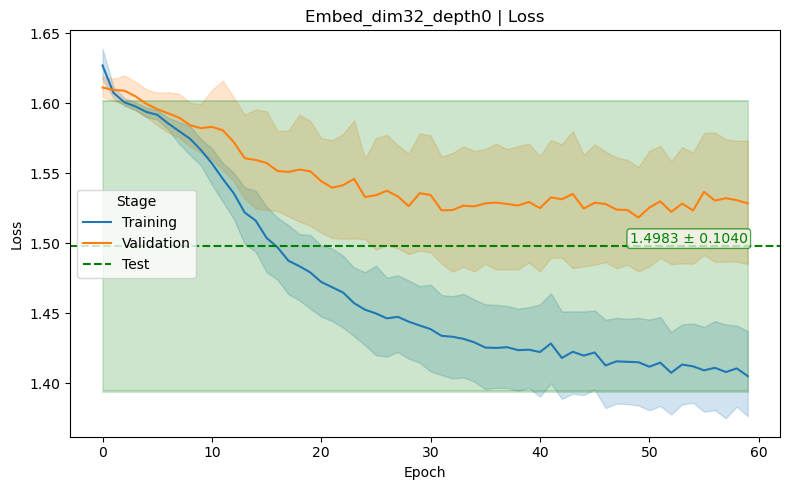

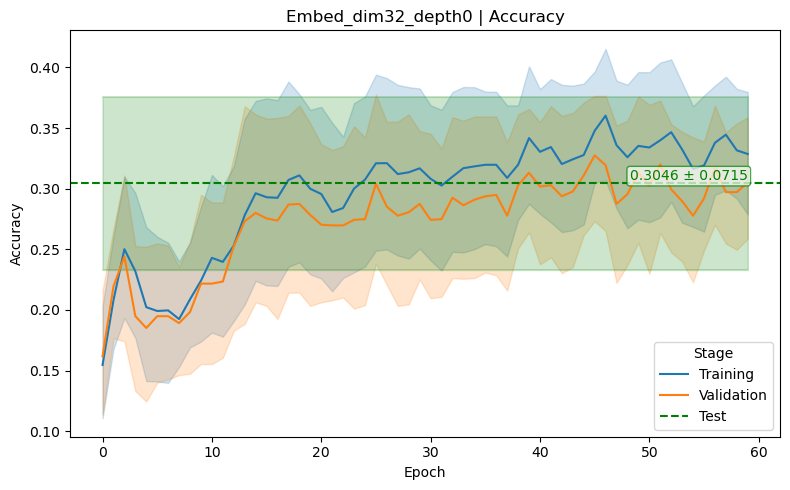

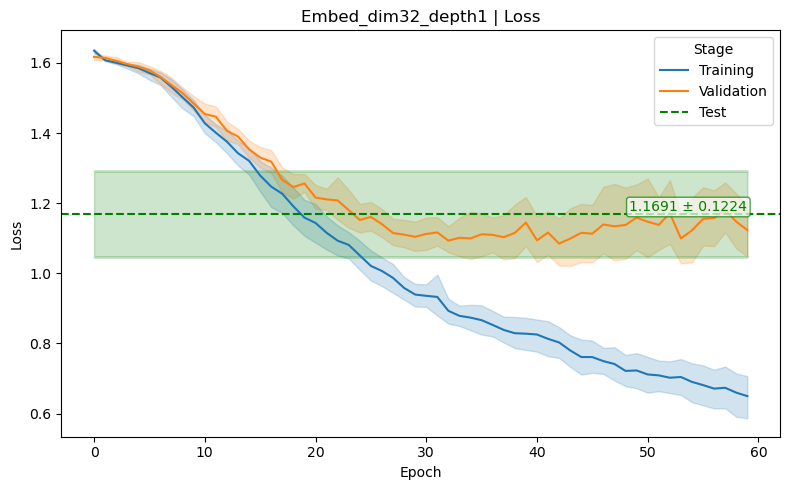

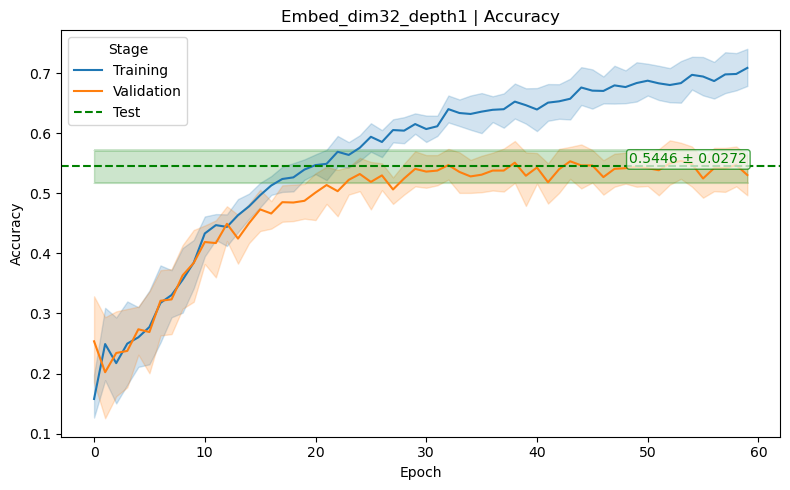

In [14]:
v.dev_plot(dev_df, summary_df, configs=['embed_dim32_depth0','embed_dim32_depth1'],metrics=['loss','accuracy'])

In [45]:
def testplot2(test_df:pd.DataFrame, configs:list=None, metrics:list=None):
    # set defaults
    configs = configs if isinstance(configs, list) else test_df['config'].unique()
    metrics = metrics if isinstance(metrics, list) else test_df['metric'].unique()

    # get n_configs (for figsize)
    n_configs = len(configs)

    # plot per metric
    for metric in metrics:

        # filter df for metric and configs
        metric_df = test_df[test_df['config'].isin(configs)]
        metric_df = metric_df[metric_df['metric'] == metric]

        plt.figure(figsize=(8, 0.5*n_configs))
        ax = sns.pointplot(
            data=metric_df, 
            y='config', 
            x='value', 
            errorbar=('ci',95), 
            linestyle='none'
        )

        ax.set_xlabel(metric.capitalize())
        ax.set_ylabel('Configuration')

In [21]:
test_node_df = pd.read_csv('./output/2025-11-20_14h54m03s_node_classif/test.csv')
test_node_df['config'] = test_node_df['config'] + '_node'

test_set_df = pd.read_csv('./output/2025-11-20_16h02m24s_set_classif/test.csv')
test_set_df['config'] = test_set_df['config'] + '_set'

test_df2 = pd.concat([test_node_df, test_set_df])


In [36]:
test_df2

,trial,config,metric,value
0,0,embed_dim32_depth0_node,loss,1.576215
1,0,embed_dim32_depth0_node,accuracy,0.342857
2,0,embed_dim32_depth0_node,precision,0.310112
3,0,embed_dim32_depth0_node,recall,0.275775
4,0,embed_dim32_depth0_node,f1,0.239205
...,...,...,...,...
715,9,embed_dim128_depth3_set,accuracy,0.468571
716,9,embed_dim128_depth3_set,precision,0.496122
717,9,embed_dim128_depth3_set,recall,0.565640
718,9,embed_dim128_depth3_set,f1,0.468408


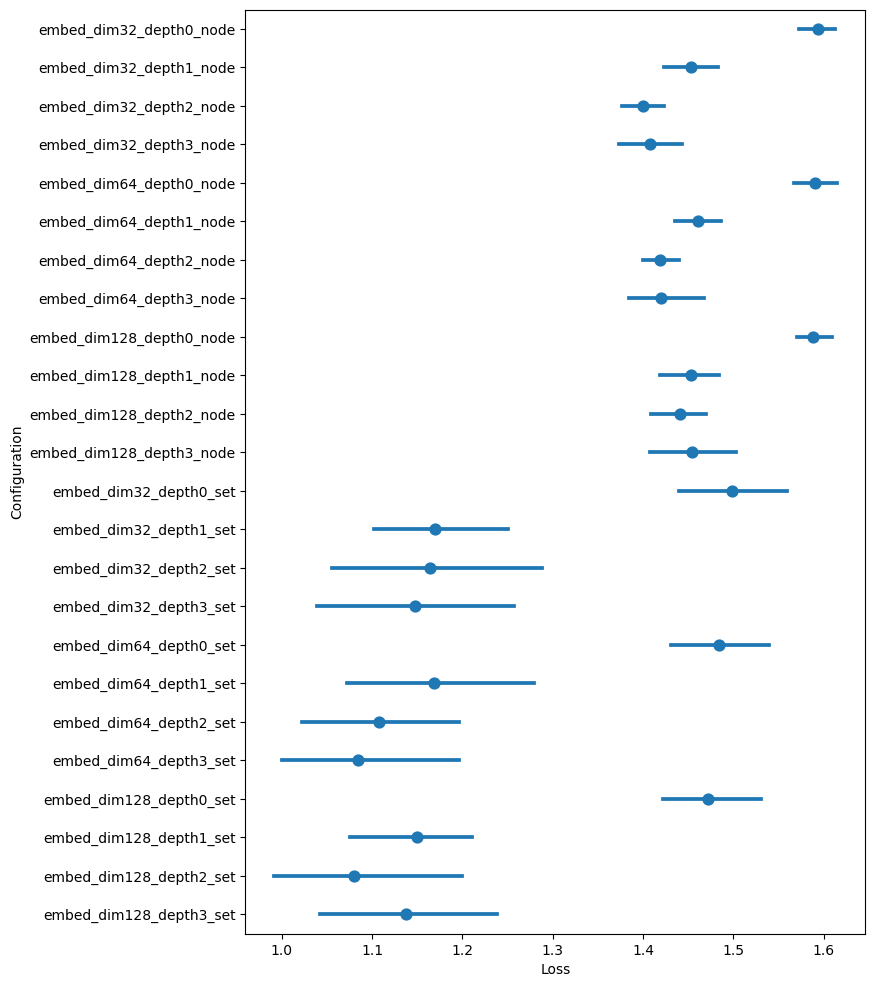

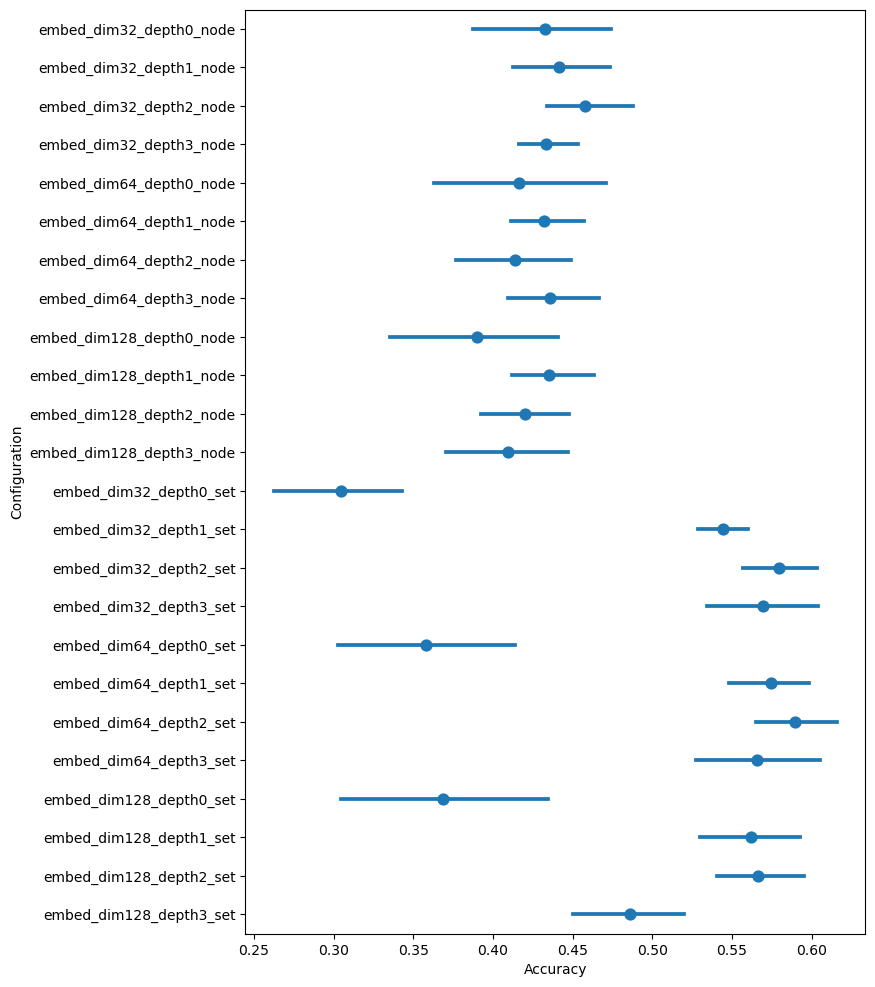

In [47]:
testplot2(test_df2, metrics=['loss','accuracy'])